## Objective
This notebook covers two tasks:
- Generate a synthetic dataset based on Gardner's Multiple Intelligences theory
- Perform exploratory data analysis (EDA) on the generated dataset

## How to use this notebook with real data

This notebook is designed to work in two modes:

| Mode | How to activate |
|---|---|
| **Synthetic (default)** | Just run the notebook as-is |
| **Real data** | Place a CSV file named `real_data.csv` inside the `data/` folder with the same column names as the synthetic dataset. The notebook will detect it automatically and skip data generation. 

**Expected columns for real data:**

```
student_name, linguistic_score, logical_math_score, spatial_score,
bodily_kinesthetic_score, interpersonal_score, intrapersonal_score,
emotional_regulation, engagement_frequency
```

All score columns must be numeric values between 0 and 10.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker

# Reproducibility
SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data"
SYNTHETIC_DATA_PATH = os.path.join(DATA_DIR, "synthetic_dataset.csv")
REAL_DATA_PATH = os.path.join(DATA_DIR, "real_data.csv")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Setup complete.")

Setup complete.


## 2. Data Source Detection

The notebook automatically checks whether a real dataset exists in `data/real_data.csv`.  
If found, it uses real data. Otherwise, it generates a synthetic dataset.

In [2]:
USE_REAL_DATA = os.path.exists(REAL_DATA_PATH)

if USE_REAL_DATA:
    print("***Real data file detected at:", REAL_DATA_PATH)
    print("***Skipping synthetic data generation.***")
else:
    print("***No real data file found.***")
    print("***Synthetic dataset will be generated automatically.***")

***No real data file found.***
***Synthetic dataset will be generated automatically.***


## 3. Synthetic Data Generation

### Design rationale

Profiles are generated with **internal coherence**, meaning scores across dimensions are not fully independent. 
This reflects pedagogical reality: a child with high logical-mathematical intelligence often shows lower bodily-kinesthetic engagement in traditional classroom settings, while a child with high interpersonal scores tends to show higher engagement frequency.

Four **base profile archetypes** were defined based on Gardner's theory to seed the generation:

| Archetype | Description |
|---|---|
| **Analytical** | High logical-math and spatial; lower bodily-kinesthetic and interpersonal |
| **Communicative** | High linguistic and interpersonal; moderate other dimensions |
| **Kinesthetic** | High bodily-kinesthetic and engagement; lower linguistic and logical-math |
| **Balanced** | Moderate scores across all dimensions; moderate socioemotional indicators |

Each student is generated from one of these archetypes with added Gaussian noise to simulate natural variation.

> **Note:** These archetypes are used only as a generation mechanism.  
> The K-Means model covered later will discover clusters **independently**, without knowledge of these labels.

For this project, some design decisions were made:

**Score thresholds:**
- "High" scores were considered as 8.5
- "Moderate" as 7.0
- "Low" as 5.5
- These values were chosen to reflect the Brazilian school grading scale (0–10),
  where scores above 7.0 are generally considered good performance
- The variation between students is defined by the NOISE_STD parameter
- These values can be adjusted according to the user's needs

**Archetype distribution:**
- `balanced` represents 40% of the sample - the largest group - reflecting the
  expected concentration of students around average performance across dimensions,
  consistent with normal distribution patterns observed in Brazilian educational
  assessments (INEP/SAEB)
- `analytical`, `communicative` and `kinesthetic` each represent 20% of the sample
  - treated as equally probable among dominant profiles, since Gardner's theory
  assigns no hierarchy or prevalence between intelligence dimensions

In [3]:
if not USE_REAL_DATA:
    fake = Faker('pt_BR')
    Faker.seed(SEED)

    N_STUDENTS = 120
    NOISE_STD = 0.8  # Standard deviation of Gaussian noise added to each score

    # Base profile archetypes
    # Format: [linguistic, logical_math, spatial, bodily_kinesthetic,
    #          interpersonal, intrapersonal, emotional_regulation, engagement_frequency]
    archetypes = {
        #                ling   log   spat  body  inter intra emot  engag
        "analytical":    [7.0,  8.5,  8.5,  5.5,  5.5,  7.0,  7.0,  7.0],
        "communicative": [8.5,  7.0,  7.0,  7.0,  8.5,  7.0,  7.0,  8.5],
        "kinesthetic":   [5.5,  5.5,  7.0,  8.5,  7.0,  7.0,  5.5,  8.5],
        "balanced":      [7.0,  7.0,  7.0,  7.0,  7.0,  7.0,  7.0,  7.0],
    }

    # Proportional distribution across archetypes
    archetype_weights = [0.20, 0.20, 0.20, 0.40]
    archetype_names = list(archetypes.keys())

    columns = [
        "student_name",
        "linguistic_score",
        "logical_math_score",
        "spatial_score",
        "bodily_kinesthetic_score",
        "interpersonal_score",
        "intrapersonal_score",
        "emotional_regulation",
        "engagement_frequency",
        "generated_archetype"  # kept for transparency - NOT used in modeling
    ]

    rows = []
    chosen_archetypes = np.random.choice(
        archetype_names, size=N_STUDENTS, p=archetype_weights
    )

    for archetype in chosen_archetypes:
        base_scores = archetypes[archetype]
        noisy_scores = np.array(base_scores) + np.random.normal(0, NOISE_STD, len(base_scores))
        # Clip to valid range [0, 10]
        noisy_scores = np.clip(noisy_scores, 0, 10).round(1)

        row = [fake.name()] + list(noisy_scores) + [archetype]
        rows.append(row)

    df = pd.DataFrame(rows, columns=columns)

    # Save to CSV
    os.makedirs(DATA_DIR, exist_ok=True)
    df.to_csv(SYNTHETIC_DATA_PATH, index=False)

    print(f"***Synthetic dataset generated: {N_STUDENTS} students, {len(columns)} columns")
    print(f"***Saved to: {SYNTHETIC_DATA_PATH}")
    print(f"\nArchetype distribution:")
    print(df['generated_archetype'].value_counts())

***Synthetic dataset generated: 120 students, 10 columns
***Saved to: ../data/synthetic_dataset.csv

Archetype distribution:
generated_archetype
balanced         46
analytical       32
communicative    22
kinesthetic      20
Name: count, dtype: int64


## 4. Load Dataset

In [4]:
if USE_REAL_DATA:
    df = pd.read_csv(REAL_DATA_PATH)
    print(f"Real dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
else:
    df = pd.read_csv(SYNTHETIC_DATA_PATH)
    print(f"Synthetic dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")

df.head()

Synthetic dataset loaded: 120 students, 10 columns


,student_name,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency,generated_archetype
0,Brenda Alves,7.9,6.7,6.7,5.8,8.7,7.2,7.0,8.3,communicative
1,Sra. Isabelly Câmara,5.9,6.7,6.7,6.4,6.9,7.3,8.5,7.1,balanced
2,Cauã Rocha,7.2,6.9,5.5,7.0,7.0,9.0,6.8,7.2,balanced
3,Dra. Aurora Pastor,5.5,4.6,7.9,9.1,7.6,6.3,6.6,7.4,kinesthetic
4,Ana Beatriz Alves,7.5,10.0,7.7,5.0,5.6,6.6,5.8,7.1,analytical


## 5. Exploratory Data Analysis (EDA)

### 5.1 Basic info and missing values

In [5]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_name              120 non-null    object 
 1   linguistic_score          120 non-null    float64
 2   logical_math_score        120 non-null    float64
 3   spatial_score             120 non-null    float64
 4   bodily_kinesthetic_score  120 non-null    float64
 5   interpersonal_score       120 non-null    float64
 6   intrapersonal_score       120 non-null    float64
 7   emotional_regulation      120 non-null    float64
 8   engagement_frequency      120 non-null    float64
 9   generated_archetype       120 non-null    object 
dtypes: float64(8), object(2)
memory usage: 9.5+ KB

Missing values:
student_name                0
linguistic_score            0
logical_math_score          0
spatial_score               0
bodily_kinesthetic_score    0
interpersonal_sc

### 5.1.1 Missing Value Treatment

If real data is provided, missing values in score columns are filled
with the column mean. This ensures the dataset remains complete
without removing student records, which would be undesirable in
small school datasets.

No missing values were found in the synthetic dataset —
this cell applies only when real data is loaded.

In [6]:
score_columns = [
    "linguistic_score", "logical_math_score", "spatial_score",
    "bodily_kinesthetic_score", "interpersonal_score", "intrapersonal_score",
    "emotional_regulation", "engagement_frequency"
]

# Fill missing values with column mean (numeric columns only)
df[score_columns] = df[score_columns].fillna(df[score_columns].mean())

# Confirm no missing values remain
print("Missing values after treatment:")
print(df[score_columns].isnull().sum())
print(f"\nDataset shape unchanged: {df.shape}")

Missing values after treatment:
linguistic_score            0
logical_math_score          0
spatial_score               0
bodily_kinesthetic_score    0
interpersonal_score         0
intrapersonal_score         0
emotional_regulation        0
engagement_frequency        0
dtype: int64

Dataset shape unchanged: (120, 10)


### 5.2 Descriptive statistics

In [7]:
df.describe()

,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,7.057500,7.102500,7.398333,6.850000,6.902500,7.095833,6.830833,7.613333
std,1.193375,1.326046,1.052567,1.284425,1.183391,0.769087,0.960812,1.098275
min,3.900000,3.900000,4.800000,3.800000,3.500000,5.100000,4.200000,5.700000
25%,6.200000,6.200000,6.675000,6.000000,6.000000,6.500000,6.200000,6.700000
50%,7.100000,7.100000,7.300000,6.850000,7.000000,7.100000,6.950000,7.500000
75%,7.800000,8.025000,8.125000,7.525000,7.700000,7.600000,7.500000,8.425000
max,10.000000,10.000000,10.000000,9.900000,9.900000,10.000000,9.000000,10.000000


### 5.3 Score distributions

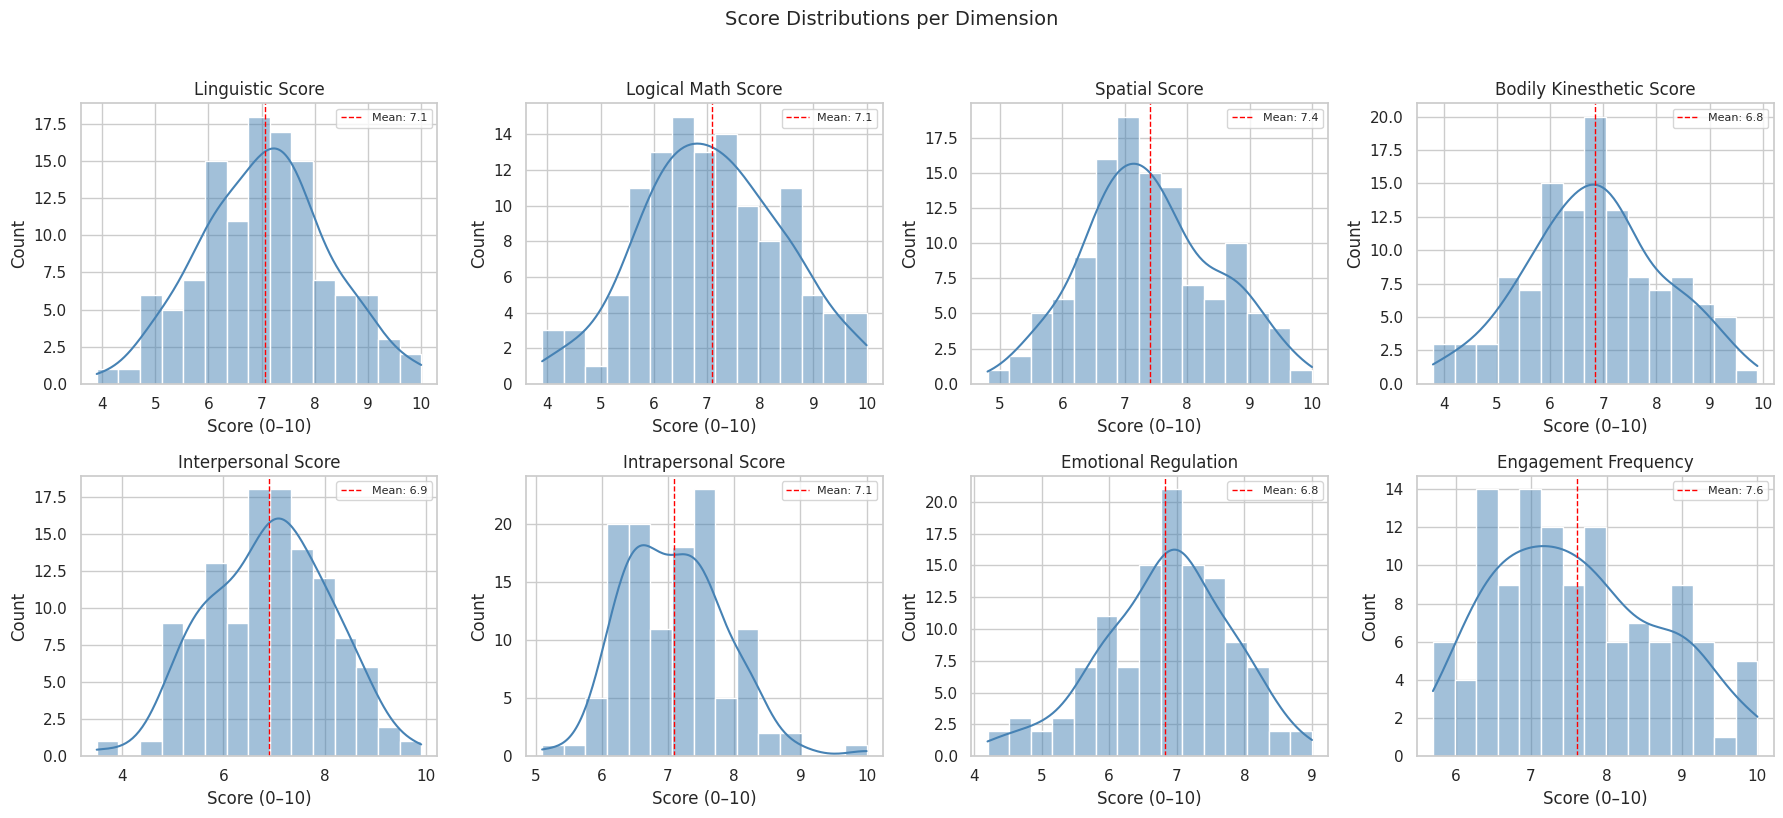

Plot saved to data/eda_distributions.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(score_columns):
    sns.histplot(df[col], bins=15, ax=axes[i], kde=True, color="steelblue")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("Score (0–10)")
    axes[i].set_ylabel("Count")
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f"Mean: {df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle("Score Distributions per Dimension", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/eda_distributions.png")

### 5.4 Correlation matrix

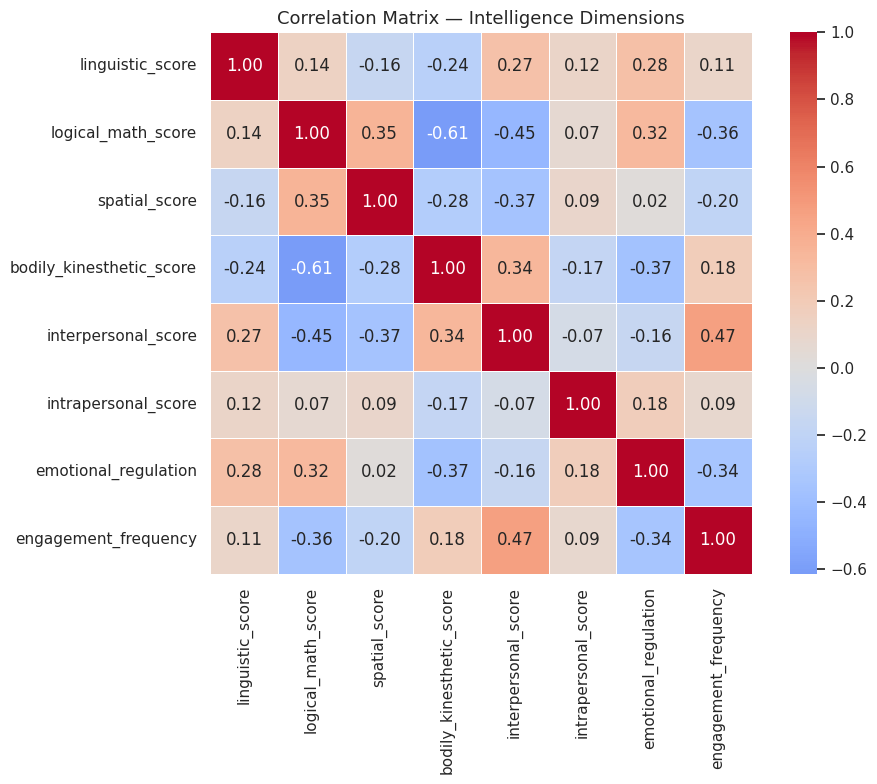

Plot saved to data/eda_correlation.png


In [9]:
corr_matrix = df[score_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5
)
plt.title("Correlation Matrix — Intelligence Dimensions", fontsize=13)
plt.tight_layout()
plt.savefig("../data/eda_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/eda_correlation.png")

### 5.5 Mean scores per dimension (radar-style bar chart)

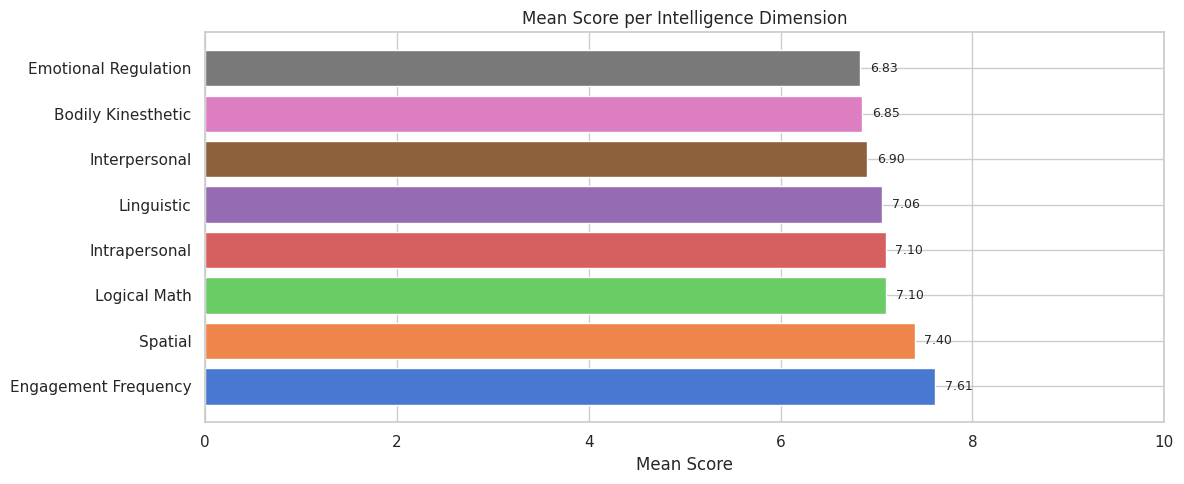

In [10]:
means = df[score_columns].mean().sort_values(ascending=False)
labels = [c.replace("_score", "").replace("_", " ").title() for c in means.index]

plt.figure(figsize=(12, 5))
bars = plt.barh(labels, means.values, color=sns.color_palette("muted", len(means)))
plt.xlim(0, 10)
plt.xlabel("Mean Score")
plt.title("Mean Score per Intelligence Dimension")
for bar, val in zip(bars, means.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("../data/eda_means.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. EDA Summary
Key observations from the exploratory analysis:

- All 8 variables are numeric and fall within the expected 0–10 range
- No missing values were found
- Score distributions are approximately normal, centered around the archetype means with added noise
- The correlation matrix reveals the expected patterns from the generation logic:
  - Positive correlations within intelligence clusters (e.g., logical-math ↔ spatial)
  - Moderate to strong negative correlations between contrasting dimensions (e.g., logical-math ↔ bodily-kinesthetic: -0.61)
  - `intrapersonal_score` shows near-zero correlations across all dimensions,
  as it was set to a uniform moderate value (7.0) across all archetypes.
  This variable may contribute less to cluster differentiation in modeling.